[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]
(https://colab.research.google.com/github/ssindiUCM/SIAM-LS26-MT1/blob/main/ML_Example2_Classification.ipynb)

# Machine Learning for Biological Modeling
## SIAM Life Sciences 2026 Mini-Tutorial: Machine Learning Section
### Example 2: Classification for Breast Cancer Data

We build and evaluate classifiers for binary breast cancer data (malignant vs. benign).

Working through this example, you will:
- fit logistic regression models with different feature sets and compare performance;
- use cross-validation to get robust performance estimates;
- apply AIC/BIC for principled model selection.
- use found model as a clinical prediction model

## 1. Setup

Import the Python packages needed for this example. We will use **scikit-learn** to access the breast cancer dataset, train logistic regression models, perform cross-validation, and evaluate model performance.

In [60]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import ranksums
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 12

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

---

## 2. Breast Cancer Wisconsin Dataset

Unlike the previous synthetic example, we now apply the same workflow to a real biomedical dataset.

The Breast Cancer Wisconsin dataset contains measurements computed from digitized images of breast mass biopsies. The objective is to classify each sample as **benign** or **malignant** based on these measurements.

Before building models, we load the data and organize it into a pandas DataFrame.

Dataset shape: (569, 32)
Target counts:


,Count
benign,357
malignant,212


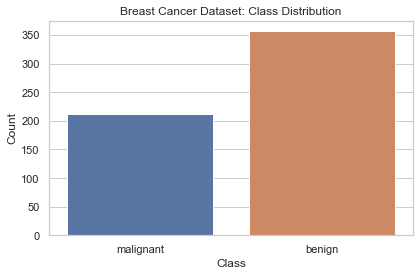

In [61]:
breast_cancer = load_breast_cancer()

bc_df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
bc_df["target"] = breast_cancer.target
bc_df["target_name"] = bc_df["target"].map({0: "malignant", 1: "benign"})

print("Dataset shape:", bc_df.shape)
print("Target counts:")
display(bc_df["target_name"].value_counts().to_frame("Count"))

plt.figure(figsize=(6, 4))
sns.countplot(data=bc_df, x="target_name", order=["malignant", "benign"])
plt.title("Breast Cancer Dataset: Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


---

## 3. Exploratory Data Analysis

Before training predictive models, it is often useful to explore how individual features differ between the two classes.

In this section we:

- Standardize each feature for visualization.
- Compare feature distributions using boxplots.
- Perform a Wilcoxon rank-sum test for each feature.
- Rank features according to their statistical significance.

This provides an initial assessment of which variables may be useful for classification, although statistical significance alone does not guarantee strong predictive performance.

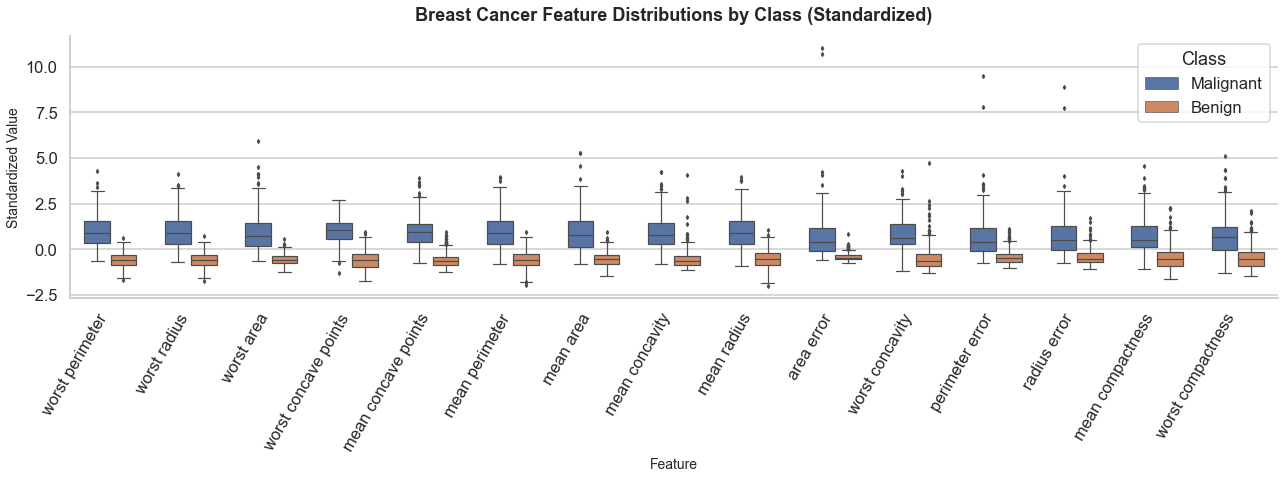

,Feature,Mean difference (Benign - Malignant),Wilcoxon rank-sum p-value
22,worst perimeter,-54.3644,0.0000
20,worst radius,-7.7550,0.0000
23,worst area,-863.3869,0.0000
27,worst concave points,-0.1078,0.0000
7,mean concave points,-0.0623,0.0000
2,mean perimeter,-37.2900,0.0000
3,mean area,-515.5862,0.0000
6,mean concavity,-0.1147,0.0000
0,mean radius,-5.3163,0.0000
13,area error,-51.5373,0.0000


In [62]:
# -----------------------------
# Use your existing breast cancer dataframe
# -----------------------------
X_df = bc_df.drop(columns=["target", "target_name"])
y_series = bc_df["target"]

class_0_name = "Malignant"
class_1_name = "Benign"

# -----------------------------
# Standardize features for plotting
# -----------------------------
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_df),
    columns=X_df.columns,
    index=X_df.index
)

# -----------------------------
# Compute rank-sum statistics on original data
# -----------------------------
rank_results = []

for col in X_df.columns:
    class_0 = X_df.loc[y_series == 0, col]
    class_1 = X_df.loc[y_series == 1, col]
    p_value = ranksums(class_0, class_1).pvalue
    mean_difference = class_1.mean() - class_0.mean()

    rank_results.append({
        "Feature": col,
        "Mean difference (Benign - Malignant)": mean_difference,
        "Wilcoxon rank-sum p-value": p_value,
    })

rank_results_df = pd.DataFrame(rank_results)

# Top 15 features by p-value
ordered_features = rank_results_df.sort_values(
    by="Wilcoxon rank-sum p-value"
)["Feature"].head(15).tolist()

# -----------------------------
# Prepare long dataframe for plotting
# -----------------------------
plot_df = X_scaled.copy()
plot_df["Class"] = y_series.values
long_df = plot_df.melt(id_vars="Class", var_name="Feature", value_name="Scaled Value")

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(18, 7))

ax = sns.boxplot(
    data=long_df,
    x="Feature",
    y="Scaled Value",
    hue="Class",
    order=ordered_features,
    palette=["#4C72B0", "#DD8452"],
    width=0.65,
    linewidth=1.2,
    fliersize=3
)

plt.xticks(rotation=60, ha="right")
ax.set_title(
    "Breast Cancer Feature Distributions by Class (Standardized)",
    fontsize=18,
    weight="bold",
    pad=15
)
ax.set_xlabel("Feature", fontsize=14)
ax.set_ylabel("Standardized Value", fontsize=14)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], [class_0_name, class_1_name], title="Class", loc="upper right", frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

# -----------------------------
# Top 10 features
# -----------------------------
top_features = rank_results_df.sort_values(
    by="Wilcoxon rank-sum p-value"
).head(10)["Feature"].tolist()

display(
    rank_results_df.sort_values("Wilcoxon rank-sum p-value").round(4)
)

---

## 4. Exhaustive Feature Selection

To identify informative predictors while reducing the risk of overfitting, we evaluate every possible combination of one, two, and three features.

The data are first divided into three subsets:

- **Training set:** used to fit candidate models.
- **Test set:** reserved for later model comparison.
- **Validation set:** held out until the final evaluation.

Only the **training set** is used during feature selection. For each candidate feature combination, a logistic regression model is evaluated using stratified 5-fold cross-validation. The mean ROC AUC across the five folds is used to rank model performance.

In addition to predictive performance, we calculate the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC), which quantify the trade-off between model fit and complexity. These metrics can help identify simpler models that achieve comparable predictive performance.

In [63]:
# -----------------------------
# Use your existing breast cancer dataframe
# -----------------------------
X_df = bc_df.drop(columns=["target", "target_name"])
y_series = bc_df["target"]
feature_list = X_df.columns.tolist()

# -----------------------------
# Split into development set and final validation set
# -----------------------------
RANDOM_STATE = 12

X_dev, X_val, y_dev, y_val = train_test_split(
    X_df,
    y_series,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_series
)

# Split development set into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_dev
)

# -----------------------------
# Cross-validation setup
# -----------------------------
cv_results = []
cv_roc_data = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

n = len(y_train)

# -----------------------------
# Evaluate feature combinations on TRAIN set only
# -----------------------------
for n_features in [1, 2, 3]:
    for feature_combo in combinations(feature_list, n_features):
        feature_name = " + ".join(feature_combo)
        X_subset = X_train[list(feature_combo)]

        fold_aucs = []
        fold_rocs = []

        for train_idx, test_idx in cv.split(X_subset, y_train):
            X_cv_train = X_subset.iloc[train_idx]
            X_cv_test = X_subset.iloc[test_idx]
            y_cv_train = y_train.iloc[train_idx]
            y_cv_test = y_train.iloc[test_idx]

            model = make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=1000),
            )

            model.fit(X_cv_train, y_cv_train)
            y_prob = model.predict_proba(X_cv_test)[:, 1]

            auc = roc_auc_score(y_cv_test, y_prob)
            fpr, tpr, _ = roc_curve(y_cv_test, y_prob)

            fold_aucs.append(auc)
            fold_rocs.append((fpr, tpr))

        # Fit once on the full TRAIN set for AIC/BIC
        full_model = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000),
        )
        full_model.fit(X_subset, y_train)

        y_prob_full = full_model.predict_proba(X_subset)[:, 1]
        ll = -log_loss(y_train, y_prob_full, normalize=False)

        # coefficients + intercept
        k = len(feature_combo) + 1

        aic = 2 * k - 2 * ll
        bic = np.log(n) * k - 2 * ll

        cv_results.append({
            "Num Features": n_features,
            "Features": feature_name,
            "Mean CV ROC AUC": np.mean(fold_aucs),
            "Std CV ROC AUC": np.std(fold_aucs),
            "Training Log-Likelihood": ll,
            "AIC": aic,
            "BIC": bic,
        })

        cv_roc_data[feature_name] = {
            "fold_rocs": fold_rocs,
            "mean_auc": np.mean(fold_aucs),
        }

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="Mean CV ROC AUC",
    ascending=False,
)

display(cv_results_df.head(10).round(3))

# -----------------------------
# Optional: ROC curves for top models
# -----------------------------
# top_cv_models = cv_results_df.head(5)
#
# plt.figure(figsize=(10, 8))
# colors = plt.cm.tab10(np.linspace(0, 1, len(top_cv_models)))
#
# for color, (_, row) in zip(colors, top_cv_models.iterrows()):
#     label = row["Features"]
#     for fpr, tpr in cv_roc_data[label]["fold_rocs"]:
#         plt.plot(fpr, tpr, color=color, linewidth=2, alpha=0.55)
#
#     plt.plot(
#         [],
#         [],
#         color=color,
#         linewidth=2.5,
#         label=f"{label} (mean AUC = {cv_roc_data[label]['mean_auc']:.2f})",
#     )
#
# plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Random classifier")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("Top Logistic Regression Models: 5-Fold Cross-Validation")
# plt.legend(loc="lower right")
# plt.tight_layout()
# plt.show()

,Num Features,Features,Mean CV ROC AUC,Std CV ROC AUC,Training Log-Likelihood,AIC,BIC
1008,3,mean texture + mean concave points + worst radius,0.994,0.003,-36.845,81.691,97.018
1011,3,mean texture + mean concave points + worst area,0.994,0.003,-37.188,82.376,97.703
1207,3,mean texture + worst radius + worst smoothness,0.994,0.006,-35.747,79.494,94.821
3934,3,area error + worst texture + worst concave points,0.994,0.004,-36.298,80.596,95.923
2950,3,mean concave points + worst texture + worst area,0.994,0.005,-34.519,77.038,92.365
4451,3,worst texture + worst area + worst concave points,0.994,0.010,-34.456,76.913,92.240
1228,3,mean texture + worst area + worst smoothness,0.994,0.007,-38.059,84.118,99.446
2940,3,mean concave points + worst radius + worst texture,0.994,0.005,-34.093,76.186,91.513
1126,3,mean texture + area error + worst concave points,0.994,0.005,-37.673,83.345,98.673
939,3,mean texture + mean smoothness + worst radius,0.993,0.005,-39.480,86.960,102.288


---

## 5. Final Model Evaluation

After identifying a promising feature set, we train a logistic regression model using the **development set** and evaluate its performance on the **held-out validation set**.

The classification threshold is selected using **Youden's J statistic** computed from the development data. This threshold is then applied to the independent validation set to generate class predictions.

Model performance is assessed using several complementary metrics, including:

- ROC curve and area under the curve (ROC AUC)
- Accuracy
- Precision
- Sensitivity (Recall)
- Specificity
- Confusion matrix

Evaluating the model on data that were not used during feature selection provides a more realistic estimate of how the classifier is expected to perform on new observations.


Validation set summary:
Number of samples: 114
Class distribution:
Benign       72
Malignant    42
Name: target, dtype: int64
Class proportions:
Benign       63.2%
Malignant    36.8%
Name: target, dtype: object

Fitted model:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

Coefficients:
               Feature  Coefficient
0  mean concave points    -2.911224
1         worst radius    -3.099070
2        worst texture    -1.256774

Intercept: 0.5058481367657703

Using Youden's J from development data to select threshold
Best threshold: 0.610
Youden's J: 0.937
Sensitivity at threshold: 0.972
Specificity at threshold: 0.965


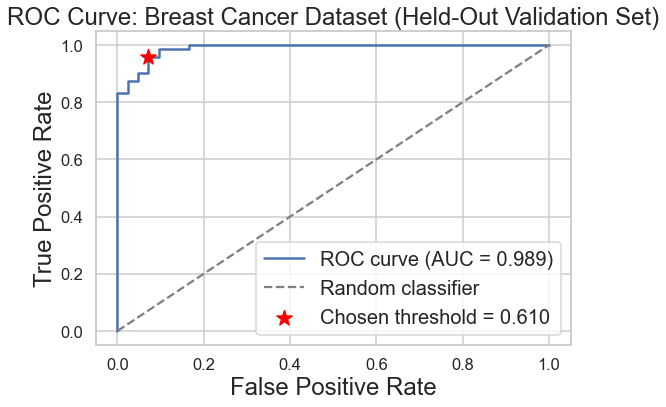


Accuracy:    91.2%
Precision:   0.956
Recall:      0.903
Sensitivity: 0.903
Specificity: 0.929
 


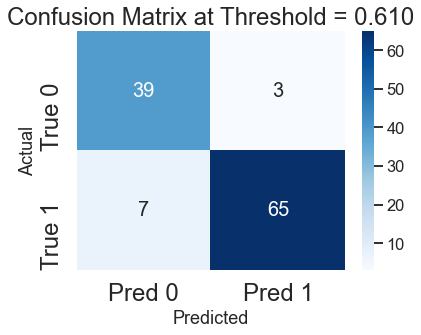

In [65]:
selected_features = ["mean concave points", "worst radius", "worst texture"]  # replace if needed
threshold = None  # set manually if you want, otherwise use Youden's J

# -----------------------------
# Development / validation split setup
# -----------------------------
# Assumes you already created:
# X_dev, X_val, y_dev, y_val = train_test_split(...)

# Make sure validation set is a DataFrame with the same columns
X_val = pd.DataFrame(X_val, columns=X_df.columns)
y_val_series = pd.Series(y_val, name="target")

# -----------------------------
# Validation set summary
# -----------------------------
print("\nValidation set summary:")
print(f"Number of samples: {len(y_val_series)}")
print("Class distribution:")
print(y_val_series.value_counts().rename(index={0: "Malignant", 1: "Benign"}))
print("Class proportions:")
print(
    (y_val_series.value_counts(normalize=True)
     .rename(index={0: "Malignant", 1: "Benign"}) * 100)
    .round(1)
    .astype(str) + "%"
)

# -----------------------------
# Fit model on the development set
# -----------------------------
X_dev_subset = X_dev[selected_features]

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000),
)

model.fit(X_dev_subset, y_dev)

# Predict probabilities on the development data
dev_probs = model.predict_proba(X_dev_subset)[:, 1]

# ROC curve / AUC on the development data
auc_dev = roc_auc_score(y_dev, dev_probs)
fpr_dev, tpr_dev, thresholds_dev = roc_curve(y_dev, dev_probs)

# -----------------------------
# Print fitted model and coefficients
# -----------------------------
print("\nFitted model:")
print(model)

log_reg = model.named_steps["logisticregression"]
coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": log_reg.coef_[0]
})

print("\nCoefficients:")
print(coef_df)
print("\nIntercept:", log_reg.intercept_[0])

print("")

# -----------------------------
# Threshold selection from development data
# -----------------------------
if threshold is None:
    youden_j = tpr_dev - fpr_dev
    best_idx = np.argmax(youden_j)

    threshold = thresholds_dev[best_idx]
    best_youden_j = youden_j[best_idx]
    best_sensitivity = tpr_dev[best_idx]
    best_specificity = 1 - fpr_dev[best_idx]

    print("Using Youden's J from development data to select threshold")
    print(f"Best threshold: {threshold:.3f}")
    print(f"Youden's J: {best_youden_j:.3f}")
    print(f"Sensitivity at threshold: {best_sensitivity:.3f}")
    print(f"Specificity at threshold: {best_specificity:.3f}")
else:
    print(f"Using user-specified threshold: {threshold:.3f}")

# -----------------------------
# Predict probabilities on validation set
# -----------------------------
X_val_subset = X_val[selected_features]
val_probs = model.predict_proba(X_val_subset)[:, 1]

# -----------------------------
# ROC curve / AUC on validation set
# -----------------------------
auc_val = roc_auc_score(y_val_series, val_probs)
fpr_val, tpr_val, thresholds_val = roc_curve(y_val_series, val_probs)

# Find the point on the validation ROC closest to the chosen threshold
threshold_idx = np.argmin(np.abs(thresholds_val - threshold))

plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, label=f"ROC curve (AUC = {auc_val:.3f})", linewidth=2.5)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.scatter(
    fpr_val[threshold_idx],
    tpr_val[threshold_idx],
    color="red",
    marker="*",
    s=250,
    label=f"Chosen threshold = {threshold:.3f}",
    zorder=5,
)
plt.xlabel("False Positive Rate", fontsize=24)
plt.ylabel("True Positive Rate", fontsize=24)
plt.title("ROC Curve: Breast Cancer Dataset (Held-Out Validation Set)", fontsize=24)
plt.legend(loc="lower right", fontsize=20)
plt.tight_layout()
plt.show()

# -----------------------------
# Classification metrics
# -----------------------------
y_pred = (val_probs >= threshold).astype(int)

cm = confusion_matrix(y_val_series, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
precision = precision_score(y_val_series, y_pred)
recall = recall_score(y_val_series, y_pred)
accuracy = accuracy_score(y_val_series, y_pred)
f1 = f1_score(y_val_series, y_pred)

print(f"\nAccuracy:    {accuracy * 100:.1f}%")
print(f"Precision:   {precision:.3f}")
print(f"Recall:      {recall:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(" ")

# -----------------------------
# Confusion matrix plot
# -----------------------------
plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"],
    annot_kws={"size": 20},
)

ax.set_xlabel("Predicted", fontsize=18)
ax.set_ylabel("Actual", fontsize=18)
ax.set_title(f"Confusion Matrix at Threshold = {threshold:.3f}", fontsize=24)
ax.tick_params(axis='both', labelsize=24)

plt.tight_layout()
plt.show()

---

## Summary

In this notebook, we applied logistic regression to the Breast Cancer Wisconsin dataset using a complete machine learning workflow.

Specifically, we:

- Explored the dataset and compared feature distributions between benign and malignant tumors.
- Ranked individual features using the Wilcoxon rank-sum test.
- Evaluated every combination of one, two, and three features using stratified 5-fold cross-validation.
- Selected a high-performing feature set based on ROC AUC.
- Trained a final logistic regression model on the development data.
- Evaluated the model on a held-out validation set using ROC curves, a confusion matrix, and classification metrics.

This workflow demonstrates the importance of separating feature selection from final model evaluation to obtain an unbiased estimate of predictive performance.

## Discussion

**Exercises** — try changing one thing at a time and observe what happens:

1. Instead of selecting the best three-feature model, evaluate the best **one-feature** and **two-feature** models. How much predictive performance is gained by adding more features?
2. Replace the selected features with the three features having the smallest Wilcoxon rank-sum p-values. Does the resulting model perform as well on the validation set?
3. Change the classification threshold from the value determined by Youden's J statistic to **0.3**, **0.5**, and **0.7**. How do sensitivity, specificity, and the confusion matrix change?
4. Replace the `StandardScaler` with a `MinMaxScaler`. Does the ROC AUC or the selected feature combination change?
5. Modify the exhaustive search to evaluate combinations of up to **four** or **five** features. Does the best-performing model improve substantially, or do you observe diminishing returns?
6. Replace logistic regression with another classifier (e.g., a decision tree, random forest, or support vector machine). Which model performs best on the held-out validation set?